In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 120)

In [4]:
data_path = "../data/Heart_failure_clinical_records_dataset.csv"  
df = pd.read_csv(data_path)
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [24]:
df.shape

(299, 13)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.837237,11.900919,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [8]:
# find missing values
df.isnull().sum()   

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [10]:
# find duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure',
       'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT'],
      dtype='object')

In [12]:
df["DEATH_EVENT"].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

In [13]:
df['time'].describe()

count    299.000000
mean     130.260870
std       77.614208
min        4.000000
25%       73.000000
50%      115.000000
75%      203.000000
max      285.000000
Name: time, dtype: float64

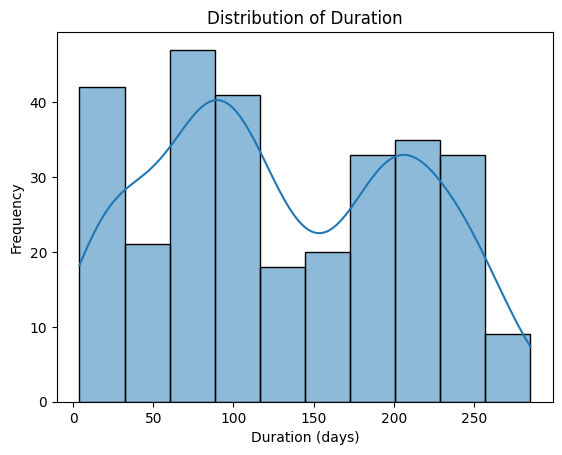

In [15]:
#Plot: distribution of duration
sns.histplot(df['time'], kde=True)
plt.title('Distribution of Duration')
plt.xlabel('Duration (days)')
plt.ylabel('Frequency')
plt.show()

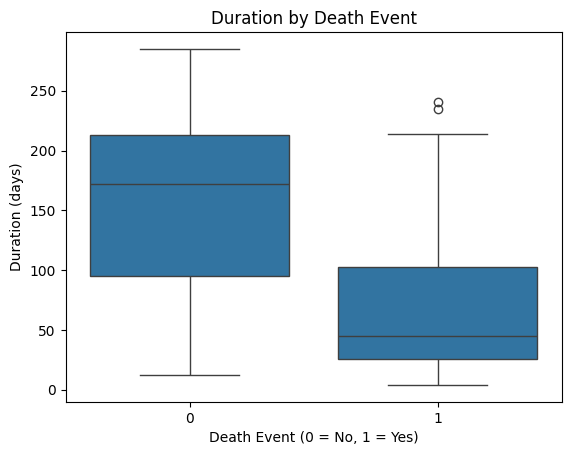

In [17]:
# Compare time by event vs no event
sns.boxplot(x='DEATH_EVENT', y='time', data=df)
plt.title('Duration by Death Event')
plt.xlabel('Death Event (0 = No, 1 = Yes)')
plt.ylabel('Duration (days)')
plt.show()  

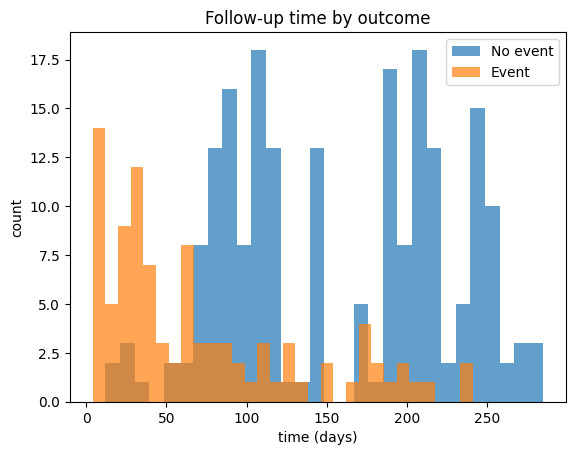

In [18]:
plt.figure()
plt.hist(df.loc[df["DEATH_EVENT"]==0, "time"], bins=30, alpha=0.7, label="No event")
plt.hist(df.loc[df["DEATH_EVENT"]==1, "time"], bins=30, alpha=0.7, label="Event")
plt.title("Follow-up time by outcome")
plt.xlabel("time (days)")
plt.ylabel("count")
plt.legend()
plt.show()

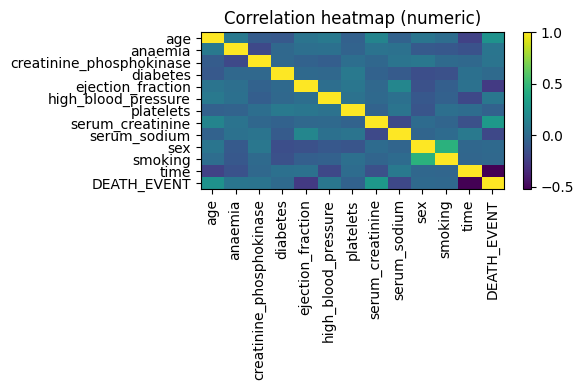

In [23]:
# check correlation between features and outcome
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

plt.figure(figsize=(6, 4))
plt.imshow(corr, aspect="auto")
plt.title("Correlation heatmap (numeric)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
# Observation notes:
# - The dataset has 299 rows and 13 columns.
# - There are no missing values or duplicates in the dataset.
# - The target variable "DEATH_EVENT" is imbalanced, with 203 cases of no event and 96 cases of event. The event rate is around 32%, which is suitable for survival analysis and classification models without extreme imbalance correction.
# - The follow-up time ("time") has a wide range, with a mean of around 130 days and a maximum of 285 days. Patients were followed up to ~9 months.
# - Patients who experienced the death event tend to have shorter follow-up times compared to those who did not experience the event.
# - The correlation heatmap shows that "ejection_fraction" and "serum_creatinine" have some correlation with the "DEATH_EVENT" outcome, which may be worth exploring further in the modeling phase.